# import package library nesscessay 

In [1]:
import torch
import torch.nn as nn
import zipfile
import gdown
import os
import torchvision
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.io import read_image
from torchvision.transforms import transforms, functional
import matplotlib.pyplot as plt
from MLP import *

In [2]:
# folder lưu trữ DL
FOLDER = 'data/'

In [3]:
# Tạo folder trong dự án
os.makedirs(name=FOLDER, exist_ok=True)

In [4]:
# Đường dẫn thư mục tập train
train_dir = 'data/train'
# Lấy tên các lable dang có trong tập DL
Labels = os.listdir(train_dir)
print(Labels)

['Cat', 'Dog']


In [5]:
# Thiết dict để ảnh xạ từ label -> idx và từ index ngược lại 
label2idx = { label: idx for idx, label in enumerate(Labels)}
print(label2idx)

{'Cat': 0, 'Dog': 1}


In [6]:
idx2label = {idx: label for label, idx in label2idx.items()}
print(idx2label)

{0: 'Cat', 1: 'Dog'}


# Tổ chức DL ảnh theo kiểu DL torch.Dataset

In [7]:
Dataset??

Init signature: Dataset()
Source:        
class Dataset(Generic[_T_co]):
    r"""An abstract class representing a :class:`Dataset`.

    All datasets that represent a map from keys to data samples should subclass
    it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
    data sample for a given key. Subclasses could also optionally overwrite
    :meth:`__len__`, which is expected to return the size of the dataset by many
    :class:`~torch.utils.data.Sampler` implementations and the default options
    of :class:`~torch.utils.data.DataLoader`. Subclasses could also
    optionally implement :meth:`__getitems__`, for speedup batched samples
    loading. This method accepts list of indices of samples of batch and returns
    list of samples.

    .. note::
      :class:`~torch.utils.data.DataLoader` by default constructs an index
      sampler that yields integral indices.  To make it work with a map-style
      dataset with non-integral indices/keys, a custom 

In [8]:
class ImageDataSet(Dataset):
    # Hàm đọc trả về đường dẫn của ảnh và nhãn tương ứng của nó
    def read_image_files(self):
        img_paths = []# List chứa đường dẫn của ảnh
        labels = []# List chứa nhãn tương ứng với từng đường dẫn
        for clss in self.label2idx.keys():
            # xét các ảnh trong thư mục nhãn được lấy ra
            for img in os.listdir(os.path.join(self.img_dir,clss)):
                try:
                    with Image.open(os.path.join(self.img_dir,clss,img)) as im:
                        im.verify() # Kiểm tra file có hợp lệ không
                        img_paths.append(os.path.join(self.img_dir,clss,img))
                        labels.append(self.label2idx[clss])
                except Exception as e:
                    print(f"skipping corrupted file: {img_paths} - {e}")
        return img_paths, labels
    def __init__(self, img_dir:str, train:bool = True, normalize: bool = True, label2idx = None, train_split: float = 0.0, img_size :tuple = (64,64),rgb2gray: bool = None):
        self.img_dir = img_dir # Đường dẫn tập DL đang xét train/test
        self.train = train # Dữ liệu đang xét là train hay tập test
        self.normalize = normalize # Có chuẩn hóa Dl ảnh không
        self.img_size = img_size # Kích thước chung của các ảnh đầu ra
        self.label2idx = label2idx # dict mã hóa nhãn --> Chỉ số
        self.train_split = train_split # Tỷ lệ của tập train default = 0 if train_split > 0 tách thành train và valid
        self.rgb2gray = rgb2gray
        self.img_paths, self.labels = self.read_image_files() # Lấy ra list đường dẫn của tất cả các ảnh và nhãn tương ứng của nó
        self.TrainData, self.ValData = None, None
        if self.train_split > 0 and self.train_split< 1:
            self.TrainData, self.ValData = train_test_split(list(zip(self.img_paths, self.labels)), train_size=train_split, shuffle=True, stratify=self.labels)
        if self.train and self.train_split:
            self.img_paths, self.labels = zip(*self.TrainData)
        if not self.train and self.train_split:
            self.img_paths, self.labels = zip(*self.ValData)
    # must overwrite - Bắt buộc phải ghi đè phương thức len
    def __len__(self):
        return len(self.img_paths)
    # must overwrite -Bắt buộc phải ghi đè phương thức __getitem__
    def __getitem__(self,index):
        img_path, label = self.img_paths[index], self.labels[index]
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean = 0.5, std = 0.5),
            transforms.Resize(size = self.img_size),
        ])
        img = transform(Image.open(img_path).convert('RGB')).float()
        if self.rgb2gray:
            img = torchvision.transforms.functional.rgb_to_grayscale(img=img, num_output_channels=1)
        return img, label

In [9]:
TrainDataSet = ImageDataSet(
    img_dir=train_dir,
    train = True,
    normalize=True,
    label2idx=label2idx,
    train_split=0,
    rgb2gray=True
)

C:\Users\chien\anaconda3\envs\study_env\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [10]:
img, label = TrainDataSet[0]
img.shape

torch.Size([1, 64, 64])

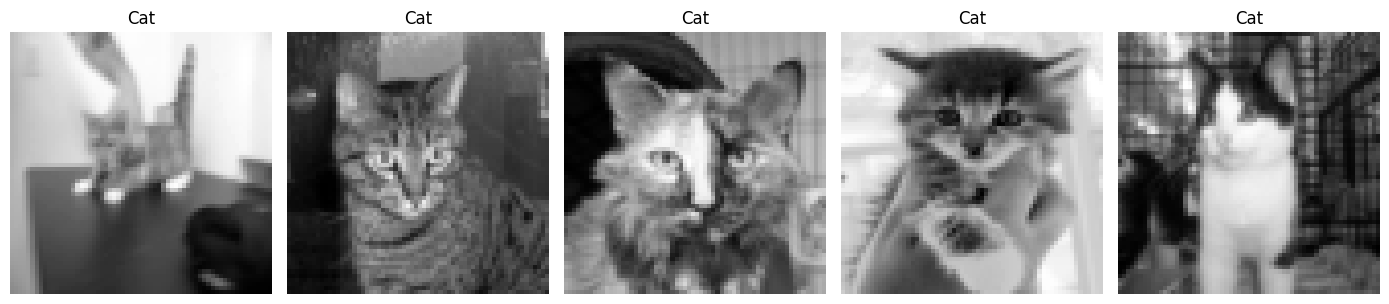

In [11]:
# Hiển thị 5 ảnh cùng nhãn của nó khi đã đọc lên
fig, axs = plt.subplots(1,5, figsize = (14,3))
for i in range(5):
    img, labelidx = TrainDataSet[i]
    # Chuyển ảnh về dạng numpy
    img_np = ((img+1)*127.5).clamp(0,255).byte().permute(1,2,0).numpy()
    axs[i].imshow(img_np, cmap = 'gray')
    axs[i].set_title(idx2label[labelidx])
    axs[i].axis("off")
plt.tight_layout()
plt.show()

# Xây dựng mô hình CNN base 

In [12]:
BaseMLP??

Init signature: BaseMLP()
Docstring:     
Helper class that provides a standard way to create an ABC using
inheritance.
Source:        
class BaseMLP(ABC):
    def __init__(self):
        self.Layers = []
        self.model = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.criterion = None
    
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def get_accuracy(self,logits,y):
        pass
    @abstractmethod
    def compute_loss(self,logits, y):
        pass
    
    def Add_layer(self,layer):
        self.Layers.append(layer)
        # dấu * ở đây có nghĩa là mỗi phần tử của list là 1 tham số của hàm nn.Sequential
        self.model = nn.Sequential(*self.Layers)
    def forward(self,X):
        if self.model is not None:
            return self.model(X)
        raise ValueError("BaseMLP.model is None !")

    def print_fmt(self,Value):
        if Value is None or len(Value) ==0:
            return float('nan')
    

In [13]:
class BaseCNN(BaseMLP):
    def __init__(self):
        super().__init__()
    def predict(self, X):
        with torch.no_grad():
            logits = self.forward(X)
            return torch.argmax(logits,dim =1)
    def get_accuracy(self, logits, y):
        try:
            return torch.mean((torch.argmax(logits,dim = 1) == torch.argmax(y,dim = 1)).float())
        except:
            return torch.mean((torch.argmax(logits,dim = 1) == y).float())
    def compute_loss(self, logits, y):
        return self.criterion(logits,y)

In [14]:
model_classifier = BaseCNN()

In [15]:
model_classifier.Add_layer(nn.Conv2d(kernel_size=3,in_channels=1,out_channels=3,stride=1, padding=1,bias=True))
model_classifier.Add_layer(nn.ReLU())
model_classifier.Add_layer(nn.MaxPool2d(kernel_size=2,stride=2))
model_classifier.Add_layer(nn.Flatten())
model_classifier.Add_layer(nn.Linear(in_features=3072, out_features=512))
model_classifier.Add_layer(nn.ReLU())
model_classifier.Add_layer(nn.Linear(in_features=512, out_features=len(label2idx.keys())))

In [16]:
model_classifier.model

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=3072, out_features=512, bias=True)
  (5): ReLU()
  (6): Linear(in_features=512, out_features=2, bias=True)
)

In [17]:
from torchsummary import summary

In [18]:
summary(model_classifier.model, input_size=(1,64,64), batch_size=512, device= 'CPU')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [512, 3, 64, 64]              30
              ReLU-2           [512, 3, 64, 64]               0
         MaxPool2d-3           [512, 3, 32, 32]               0
           Flatten-4                [512, 3072]               0
            Linear-5                 [512, 512]       1,573,376
              ReLU-6                 [512, 512]               0
            Linear-7                   [512, 2]           1,026
Total params: 1,574,432
Trainable params: 1,574,432
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 8.00
Forward/backward pass size (MB): 124.01
Params size (MB): 6.01
Estimated Total Size (MB): 138.01
----------------------------------------------------------------


In [ ]:
model_classifier.fit(dataset=TrainDataSet,n_epochs=90, optimizer='Adam', criterion='CE',verbose=2, batch_size=256,validation_split=0.2)

C:\Users\chien\anaconda3\envs\study_env\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  0%|                                                                                           | 0/90 [00:00<?, ?it/s]

Epoch [   1/90]


C:\Users\chien\anaconda3\envs\study_env\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  1%|▉                                                                               | 1/90 [01:45<2:35:46, 105.02s/it]

Loss = 0.9810 - Accuracy = 0.5492 - Loss_Validation = 0.6625 - Accracy_Validation = 0.6048
Epoch [   2/90]


  2%|█▊                                                                              | 2/90 [03:28<2:32:45, 104.15s/it]

...

Loss = 0.0257 - Accuracy = 0.9923 - Loss_Validation = 3.5006 - Accracy_Validation = 0.6396
Epoch [  35/90]


 39%|███████████████████████████████                                                 | 35/90 [58:56<1:14:49, 81.63s/it]

Loss = 0.0241 - Accuracy = 0.9928 - Loss_Validation = 3.7130 - Accracy_Validation = 0.6364
Epoch [  36/90]


 40%|███████████████████████████████▏                                              | 36/90 [1:00:18<1:13:29, 81.66s/it]

Loss = 0.0203 - Accuracy = 0.9950 - Loss_Validation = 3.7597 - Accracy_Validation = 0.6382
Epoch [  37/90]
